<a href="https://colab.research.google.com/github/vitor-007/APM-turma5/blob/main/vitorreina_TratamentoCensus0915.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline de Análise de Dados [Census]

## Importação de Bibliotecas

*   Pandas
*   Numpy
*   MatPlotLib
*   SeaBorn




In [46]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [47]:
import pandas as pd # organiza arrays
import numpy as np # calculos complexos
import matplotlib.pyplot as plt # poder ver execuções matematicas complexas
import seaborn as sns # visualização de dados
import plotly.express as px # expor dados via api

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## Carregamento dos Dados da Base


In [4]:
base_census = pd.read_csv('/content/drive/MyDrive/am-t5/census.csv')

In [5]:
base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
base_census.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Caracteristícas da Base
- População amostral: 32.561
- Minorias importante: idade = 28 e 90, Ed. = 9 e 16, ht = 40 e 99
- Média amostral: idade: 38.58, Ed.= 10,
Gain = 1077.65, Loss = 87.30, ht= 40.44
-  Desvio Padrão [Limites]: idade 24.94, Ed. = 7.51, Gain = -6757.64, Loss = -315.66, ht = 28,9

In [7]:
grafico_classe = px.treemap(base_census, path = ['workclass' , 'age'])
grafico_classe.show()

In [8]:
grafico_classe_ora = px.treemap(base_census, path = ['occupation', 'relationship', 'age'])
grafico_classe_ora.show()

In [9]:
grafico_finetune_erg = px.parallel_categories(base_census, dimensions = ['education', 'race', 'income'])
grafico_finetune_erg.show()


In [10]:
base_census.isnull().sum()

,0
age,0
workclass,0
final-weight,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [11]:
base_census[base_census.isin([' ?']).any(axis=1)]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,?,>50K
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,?,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,?,<=50K
61,32,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32530,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32531,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32539,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32541,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [12]:
base_census[(base_census['age'] <= 24) & (base_census.isin([' ?']).any(axis=1))]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,?,<=50K
106,17,?,304873,10th,6,Never-married,?,Own-child,White,Female,34095,0,32,United-States,<=50K
201,19,?,170653,HS-grad,9,Never-married,?,Own-child,White,Male,0,0,40,Italy,<=50K
243,20,?,119156,Some-college,10,Never-married,?,Own-child,White,Male,0,0,20,United-States,<=50K
266,19,?,218956,Some-college,10,Never-married,?,Own-child,White,Male,0,0,24,Canada,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32275,20,?,99891,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
32310,21,?,205939,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
32314,18,Never-worked,153663,Some-college,10,Never-married,?,Own-child,White,Male,0,0,4,United-States,<=50K
32335,18,?,156608,11th,7,Never-married,?,Own-child,White,Female,0,0,25,United-States,<=50K


In [13]:
def normalizarEstudantes(df):
  condition_age_24 = (df['age'] < 24)
  df.loc[condition_age_24 & (df['workclass'] == ' ?'), 'workclass'] = 'Dependent'
  df.loc[condition_age_24 & (df['occupation'] == ' ?'), 'occupation'] = 'Student'
  return df
base_census = normalizarEstudantes(base_census)

In [14]:
base_census.loc[base_census['age'] < 18]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
106,17,Dependent,304873,10th,6,Never-married,Student,Own-child,White,Female,34095,0,32,United-States,<=50K
209,17,Private,65368,11th,7,Never-married,Sales,Own-child,White,Female,0,0,12,United-States,<=50K
262,17,Private,245918,11th,7,Never-married,Other-service,Own-child,White,Male,0,0,12,United-States,<=50K
271,17,Private,191260,9th,5,Never-married,Other-service,Own-child,White,Male,1055,0,24,United-States,<=50K
335,17,Private,270942,5th-6th,3,Never-married,Other-service,Other-relative,White,Male,0,0,48,Mexico,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31772,17,Dependent,256173,10th,6,Never-married,Student,Own-child,White,Female,0,0,15,United-States,<=50K
31864,17,Private,214787,12th,8,Never-married,Adm-clerical,Own-child,White,Female,0,0,25,United-States,<=50K
31959,17,Private,24090,HS-grad,9,Never-married,Exec-managerial,Own-child,White,Female,0,0,35,United-States,<=50K
32282,17,Private,311907,11th,7,Never-married,Other-service,Own-child,White,Male,0,0,25,United-States,<=50K


# Analilise de Anomalias de Dados [Census]


**Enunciado: Auditoria e Higienização de Dados Censitários**

Vamos analizar e estruturar a ingestão de um novo pipeline de dados sociodemográficos focado no desenvolvimento de modelos de inteligência artificial. O arquivo **census.csv** foi extraído de um sistema legado, mas o processo automatizado falhou antes mesmo da etapa de modelagem estatística. Como futuros cientistas da computação e engenheiros de dados, a missão de vocês é realizar uma auditoria rigorosa neste arquivo para garantir a integridade da informação.

Dicas de Investigação e Solução

* **Identificação de Linhas Infiltradas**: Ao forçarem o carregamento inicial (pulando as linhas defeituosas do topo), observem o comportamento dos tipos de dados informados pelo `.dtypes`. Se colunas que deveriam ser numéricas (`age` ou `hour-per-week`) foram lidas como `object`, existem *strings* perdidas no meio da massa de dados. O cabeçalho e fragmentos de texto corrompido estão repetidos ao longo do arquivo.
* **Inconsistência Categórica e Caracteres de Escape:** Analisem a distribuição de classes na coluna `income` através do `.value_counts()`. A mesma classe de renda foi acidentalmente dividida em múltiplas categorias distintas devido a falhas de exportação com caracteres de escape textuais (como `\<=50K` versus `<=50K`).
* **Dados Faltantes Não Convencionais:** Avaliem como a ausência de informação foi mascarada pelo sistema de origem. Em bases censitárias clássicas, campos em branco (como `workclass` e `native-country`) frequentemente não aparecem como `NaN` estruturados, mas são substituídos por marcadores categóricos arbitrários, como o caractere `?`.
* **Tratamento de Espaçamento:** A separação por vírgulas pode conter espaços em branco residuais no início das palavras, prejudicando filtros e agrupamentos futuros. O parâmetro `skipinitialspace=True` na leitura do Pandas é um atalho eficiente para padronizar as bordas do texto.

In [15]:
base_census['age'] = pd.to_numeric(base_census['age'], errors='coerce')
base_census['hour-per-week'] = pd.to_numeric(base_census['hour-per-week'], errors='coerce')

base_census = base_census.dropna(subset=['age', 'hour-per-week'])
base_census['age'] = base_census['age'].astype(int)
base_census['hour-per-week'] = base_census['hour-per-week'].astype(int)

base_census['income'] = base_census['income'].astype(str).str.replace('\\', '', regex=False)

base_census = base_census.replace('?', np.nan)

In [16]:
print("Tipos de Dados Corrigidos")
print(base_census.dtypes)

print("\nDistribuição de Renda Higienizada")
contagem_renda = base_census['income'].value_counts()
print(contagem_renda)

print("\nContagem de Dados Faltantes (NaN)")
faltantes = base_census.isnull().sum()
faltantes_reais = faltantes[faltantes > 0]
print(faltantes_reais)

Tipos de Dados Corrigidos
age                int64
workclass         object
final-weight       int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loos       int64
hour-per-week      int64
native-country    object
income            object
dtype: object

Distribuição de Renda Higienizada
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Contagem de Dados Faltantes (NaN)
Series([], dtype: int64)


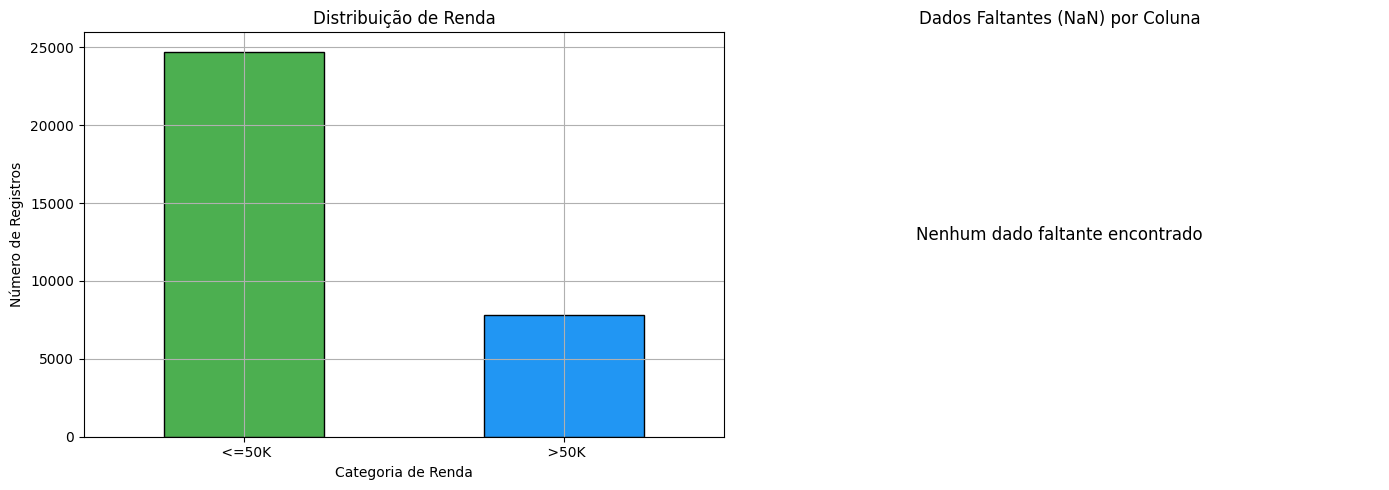

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1
contagem_renda.plot.bar(ax=axes[0], color=['#4CAF50', '#2196F3'], edgecolor='black',
                        title='Distribuição de Renda', rot=0, grid=True)
axes[0].set(xlabel='Categoria de Renda', ylabel='Número de Registros')

# Gráfico 2
if not faltantes_reais.empty:
    faltantes_reais.plot.bar(ax=axes[1], color='#F44336', edgecolor='black',
                             title='Dados Faltantes (NaN) por Coluna', rot=45, grid=True)
    axes[1].set(xlabel='Colunas', ylabel='Quantidade de Valores Nulos')
else:
    axes[1].text(0.5, 0.5, 'Nenhum dado faltante encontrado', ha='center', va='center', fontsize=12)
    axes[1].set_title('Dados Faltantes (NaN) por Coluna')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [18]:
def normalizarRetired(df):
  condition_age_62 = df['age']>62
  df.loc[condition_age_62 & (df['workclass']==' ?'), 'workclass' ] = 'Social Security'
  df.loc[condition_age_62 & (df['occupation']==' ?'),'occupation'] = 'Retired'
  return df
base_census = normalizarRetired(base_census)

In [19]:
base_census.loc[base_census['age']>=62]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
74,79,Private,124744,Some-college,10,Married-civ-spouse,Prof-specialty,Other-relative,White,Male,0,0,20,United-States,<=50K
77,67,Social Security,212759,10th,6,Married-civ-spouse,Retired,Husband,White,Male,0,0,2,United-States,<=50K
100,76,Private,124191,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
144,70,Private,105376,Some-college,10,Never-married,Tech-support,Other-relative,White,Male,0,0,40,United-States,<=50K
148,64,Private,181232,11th,7,Married-civ-spouse,Craft-repair,Husband,White,Male,0,2179,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32515,66,Federal-gov,47358,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,3471,0,40,United-States,<=50K
32525,81,Social Security,120478,Assoc-voc,11,Divorced,Retired,Unmarried,White,Female,0,0,1,?,<=50K
32539,71,Social Security,287372,Doctorate,16,Married-civ-spouse,Retired,Husband,White,Male,0,0,10,United-States,>50K
32542,72,Social Security,129912,HS-grad,9,Married-civ-spouse,Retired,Husband,White,Male,0,0,25,United-States,<=50K


In [20]:
base_census[(base_census['age'] >62 ) & (base_census.isin([' ?']).any(axis=1))]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
729,65,Self-emp-not-inc,118474,11th,7,Married-civ-spouse,Exec-managerial,Husband,White,Male,9386,0,59,?,>50K
1036,66,Self-emp-inc,150726,9th,5,Married-civ-spouse,Exec-managerial,Husband,White,Male,1409,0,1,?,<=50K
1676,64,Social Security,168340,HS-grad,9,Married-civ-spouse,Retired,Husband,White,Male,0,0,40,?,>50K
3247,64,Self-emp-inc,132832,HS-grad,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,20051,0,40,?,>50K
4326,64,Private,164204,1st-4th,2,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,53,?,<=50K
4772,66,Local-gov,222810,Some-college,10,Divorced,Other-service,Other-relative,White,Female,7896,0,40,?,>50K
5201,76,Self-emp-not-inc,33213,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,30,?,>50K
6129,63,Private,88653,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,?,<=50K
11187,65,Private,271092,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,?,<=50K
12830,81,Private,201398,Masters,14,Widowed,Prof-specialty,Unmarried,White,Male,0,0,60,?,<=50K


In [21]:
base_census[(base_census.isin([' ?']).any(axis=1))]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,?,>50K
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,?,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,?,<=50K
61,32,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32510,39,Private,107302,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,?,>50K
32525,81,Social Security,120478,Assoc-voc,11,Divorced,Retired,Unmarried,White,Female,0,0,1,?,<=50K
32530,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32531,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K


In [22]:
base_census[
    ((base_census['age'] >= 24 ) & (base_census['age'] <= 62 ))
    &
     ((base_census['workclass']==' ?') & (base_census['capital-gain']==0))]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
61,32,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
69,25,?,200681,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
128,35,?,129305,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,0,40,United-States,<=50K
149,43,?,174662,Some-college,10,Divorced,?,Not-in-family,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32477,49,?,114648,12th,8,Divorced,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
32490,60,?,134152,9th,5,Divorced,?,Not-in-family,Black,Male,0,0,35,United-States,<=50K
32530,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32531,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K


In [23]:
def normalizarNoMarket1(df):
  condition_unemployed = ((df['age'] >= 24 ) & (df['age'] <= 40 )) & (df['capital-gain']==0 )
  df.loc[condition_unemployed & (df['workclass']==' ?'), 'workclass' ] = 'Unemployed'
  df.loc[condition_unemployed & (df['occupation']==' ?'),'occupation'] = 'No market'
  return df
base_census = normalizarNoMarket1(base_census)

base_census[(base_census['age'] >=24 ) & (base_census['age'] <=62 ) & (base_census['workclass']=='Unemployed')]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
61,32,Unemployed,293936,7th-8th,4,Married-spouse-absent,No market,Not-in-family,White,Male,0,0,40,?,<=50K
69,25,Unemployed,200681,Some-college,10,Never-married,No market,Own-child,White,Male,0,0,40,United-States,<=50K
128,35,Unemployed,129305,HS-grad,9,Married-civ-spouse,No market,Husband,White,Male,0,0,40,United-States,<=50K
347,30,Unemployed,151989,Assoc-voc,11,Divorced,No market,Unmarried,White,Female,0,0,40,United-States,<=50K
408,28,Unemployed,123147,Some-college,10,Married-civ-spouse,No market,Wife,White,Female,0,1887,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32062,26,Unemployed,375313,Some-college,10,Never-married,No market,Own-child,Asian-Pac-Islander,Male,0,0,40,Philippines,<=50K
32075,27,Unemployed,147638,Masters,14,Never-married,No market,Not-in-family,Other,Female,0,0,40,Japan,<=50K
32103,34,Unemployed,330301,7th-8th,4,Separated,No market,Unmarried,Black,Female,0,0,40,United-States,<=50K
32530,35,Unemployed,320084,Bachelors,13,Married-civ-spouse,No market,Wife,White,Female,0,0,55,United-States,>50K


In [24]:
base_census[(base_census['age'] >=24 ) & (base_census['age'] <=62 ) & (base_census['workclass']==' ?') & (base_census['hour-per-week']>0)]


,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
149,43,?,174662,Some-college,10,Divorced,?,Not-in-family,White,Female,0,0,40,United-States,<=50K
154,52,?,252903,HS-grad,9,Divorced,?,Not-in-family,White,Male,0,0,45,United-States,>50K
187,53,?,135105,Bachelors,13,Divorced,?,Not-in-family,White,Female,0,0,50,United-States,<=50K
226,60,?,24215,10th,6,Divorced,?,Not-in-family,Amer-Indian-Eskimo,Female,0,0,10,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32201,49,?,113913,HS-grad,9,Married-civ-spouse,?,Wife,White,Female,0,0,60,United-States,<=50K
32291,59,?,120617,Some-college,10,Never-married,?,Not-in-family,Black,Female,0,0,40,United-States,<=50K
32477,49,?,114648,12th,8,Divorced,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
32490,60,?,134152,9th,5,Divorced,?,Not-in-family,Black,Male,0,0,35,United-States,<=50K


In [25]:
def normalizarIndependentWorker(df):
  condition_Independent = ((df['age'] >= 24 ) & (df['age'] <= 62 )) & (df['capital-gain']==0) & (df['hour-per-week']>0)
  df.loc[condition_Independent & (df['workclass']==' ?'), 'workclass' ] = 'Independent'
  df.loc[condition_Independent & (df['occupation']==' ?'),'occupation'] = 'Family Support'
  return df
base_census = normalizarIndependentWorker(base_census)

In [26]:
base_census[(base_census['age'] >=24 ) & (base_census['age'] <=62 ) & (base_census['workclass']=='Independent') & (base_census['hour-per-week']>0)]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
27,54,Independent,180211,Some-college,10,Married-civ-spouse,Family Support,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
149,43,Independent,174662,Some-college,10,Divorced,Family Support,Not-in-family,White,Female,0,0,40,United-States,<=50K
154,52,Independent,252903,HS-grad,9,Divorced,Family Support,Not-in-family,White,Male,0,0,45,United-States,>50K
187,53,Independent,135105,Bachelors,13,Divorced,Family Support,Not-in-family,White,Female,0,0,50,United-States,<=50K
226,60,Independent,24215,10th,6,Divorced,Family Support,Not-in-family,Amer-Indian-Eskimo,Female,0,0,10,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32201,49,Independent,113913,HS-grad,9,Married-civ-spouse,Family Support,Wife,White,Female,0,0,60,United-States,<=50K
32291,59,Independent,120617,Some-college,10,Never-married,Family Support,Not-in-family,Black,Female,0,0,40,United-States,<=50K
32477,49,Independent,114648,12th,8,Divorced,Family Support,Other-relative,Black,Male,0,0,40,United-States,<=50K
32490,60,Independent,134152,9th,5,Divorced,Family Support,Not-in-family,Black,Male,0,0,35,United-States,<=50K


In [27]:
def normalizarInvestors(df):
  condition_Investors = ((df['age'] >= 24 ) & (df['age'] <= 62 )) & (df['capital-gain']>0) & (df['hour-per-week']>0)
  df.loc[condition_Investors & (df['workclass']==' ?'), 'workclass' ] = 'Financial Market'
  df.loc[condition_Investors & (df['occupation']==' ?'),'occupation'] = 'Investors'
  return df
base_census = normalizarInvestors(base_census)

In [28]:
def normalizarStateless(df):
  condition_Stateless = (df['race'] != 'White')
  df.loc[condition_Stateless & (df['native-country']==' ?'), 'native-country' ] = 'Stateless'
  return df

base_census = normalizarStateless(base_census)

In [29]:
base_census[(base_census['native-country']==' ?')]

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income


# Pré - Processamentos Escalonar [Census]


In [30]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

categorical_features = [1, 3, 5, 6, 7, 8, 9, 13]
numerical_features = [0, 2, 4, 10, 11, 12]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)


In [31]:
X_census = base_census.iloc[:, 0:14].values

In [32]:
X_census

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      dtype=object)

In [33]:
Y_census = base_census.iloc[:, 14].values

In [34]:
Y_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [35]:
(X_census[:, 2].min() - X_census[:, 2].max())

-1472420

In [36]:
(X_census[:, 10].min() - X_census[:, 10].max())

-99999

## Encoder de Label para Vetores [Dados Categoricos]


In [37]:
label_workclass = LabelEncoder()
label_education = LabelEncoder()
label_marital = LabelEncoder()
label_occupation = LabelEncoder()
label_relationship = LabelEncoder()
label_race = LabelEncoder()
label_sex = LabelEncoder()
label_country = LabelEncoder()


In [38]:
X_census[:, 1] = label_workclass.fit_transform(X_census[:, 1])
X_census[:, 3] = label_education.fit_transform(X_census[:, 3])
X_census[:, 5] = label_marital.fit_transform(X_census[:, 5])
X_census[:, 6] = label_occupation.fit_transform(X_census[:, 6])
X_census[:, 7] = label_relationship.fit_transform(X_census[:, 7])
X_census[:, 8] = label_race.fit_transform(X_census[:, 8])
X_census[:, 9] = label_sex.fit_transform(X_census[:, 9])
X_census[:, 13] = label_country.fit_transform(X_census[:, 13])

In [39]:
X_census [0]

array([39, 6, 77516, 9, 13, 4, 0, 1, 4, 1, 2174, 0, 40, 38], dtype=object)

## Encoder de Label Onehot Matriciação [Dados Categoricos]

In [40]:
onehotencoder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [1,3,5,6,7,8,9,13])],remainder='passthrough')

In [41]:
X_census = onehotencoder.fit_transform(X_census).toarray()

In [42]:
X_census[0]

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e

In [43]:
X_census.shape

(32561, 116)

In [44]:
X_census[4].min()

np.float64(0.0)

In [45]:
scaler_census = StandardScaler()
X_census = scaler_census.fit_transform(X_census)

## Divisão das Amostras

In [48]:
from sklearn.model_selection import train_test_split

In [51]:
X_census[2].max(), X_census[2].min()

(np.float64(4.771493821087128), np.float64(-0.9228406775397052))

In [52]:
X_census_train, X_census_test, Y_census_train, Y_census_test = train_test_split(X_census, Y_census, test_size=0.15, random_state=0)

In [55]:
X_census_train.shape, Y_census_train.shape

((27676, 116), (27676,))

In [56]:
X_census_test.shape, Y_census_test.shape

((4885, 116), (4885,))

In [58]:
import pickle

with open ('/content/drive/MyDrive/am-t5/census.pkl', 'wb') as f:
  pickle.dump([X_census_train, Y_census_train, X_census_test, Y_census_test], f)